# Week 7

# 1. ARCH and GARCH models
# 2. Out of sampling forecasting

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from scipy.stats.distributions import chi2

from statsmodels.tsa.arima.model import ARIMA

In [8]:
spdata = pd.read_csv('data7_SP500.csv', header=0, index_col=0, na_values = ".")
spdata.index = pd.to_datetime(spdata.index)
spdata = spdata.ffill() #forward filling to fill in the data
spdata = spdata['2013':'2022']
spdata.columns = ['price']
spdata.head(3)

,price
DATE,
2013-03-04,1525.20
2013-03-05,1539.79
2013-03-06,1541.46


In [10]:
spdata['ret'] = spdata.price.pct_change()*100
spdata['sqret'] = spdata.ret.mul(spdata.ret)

In [14]:
spdata.head(3)

,price,ret,sqret
DATE,,,
2013-03-04,1525.20,NaN,NaN
2013-03-05,1539.79,0.956596,0.915076
2013-03-06,1541.46,0.108456,0.011763


Text(0.5, 1.0, 'SP 500 returns')

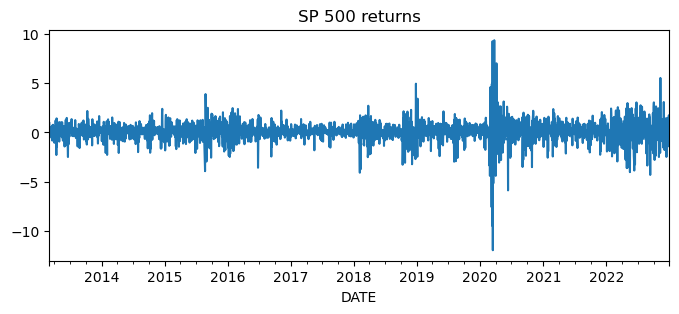

In [16]:
spdata.ret.plot(figsize=(8,3))
plt.title("SP 500 returns")

Text(0.5, 1.0, 'SP 500 volatility')

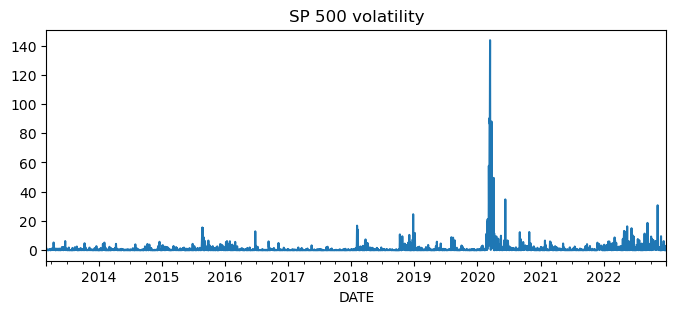

In [18]:
spdata.sqret.plot(figsize=(8,3))
plt.title("SP 500 volatility")

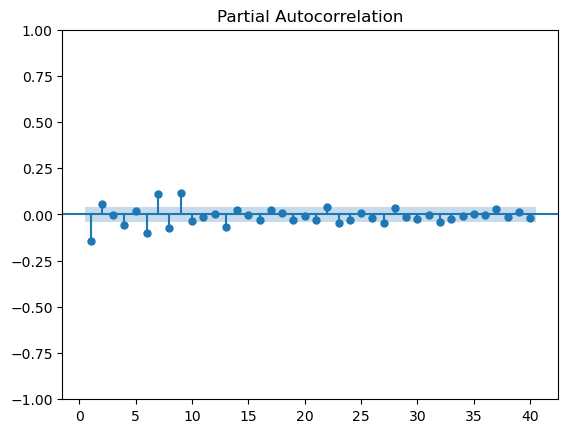

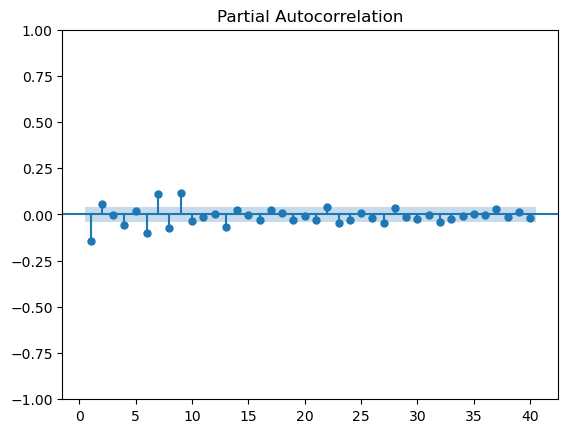

In [20]:
sgt.plot_pacf(spdata.ret[1:], lags=40, zero=False)

In [22]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.5/927.5 kB 30.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [24]:
import arch
from arch import arch_model

In [32]:
model_arch1 = arch_model(spdata.ret[1:], mean = 'Constant', vol= 'ARCH', p=1)
res_arch1 = model_arch1.fit(update_freq=2)
res_arch1.summary

Iteration:      2,   Func. Count:     14,   Neg. LLF: 5955.427562479732
Iteration:      4,   Func. Count:     27,   Neg. LLF: 3509.5296531056733
Iteration:      6,   Func. Count:     34,   Neg. LLF: 3509.5295264204888
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3509.5295264204547
            Iterations: 6
            Function evaluations: 34
            Gradient evaluations: 6


<bound method ARCHModelResult.summary of                       Constant Mean - ARCH Model Results                      
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3509.53
Distribution:                  Normal   AIC:                           7025.06
Method:            Maximum Likelihood   BIC:                           7042.61
                                        No. Observations:                 2564
Date:                Mon, Mar 03 2025   Df Residuals:                     2563
Time:                        13:34:43   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0972  

In [34]:
model_arch1 = arch_model(spdata.ret[1:], mean = 'Constant', vol= 'ARCH', p=7)
res_arch1 = model_arch1.fit(update_freq=2)
res_arch1.summary

Iteration:      2,   Func. Count:     26,   Neg. LLF: 6083.549759818088
Iteration:      4,   Func. Count:     50,   Neg. LLF: 3682.683041999348
Iteration:      6,   Func. Count:     72,   Neg. LLF: 3964.3799511896914
Iteration:      8,   Func. Count:     94,   Neg. LLF: 3387.9136752541044
Iteration:     10,   Func. Count:    117,   Neg. LLF: 3283.4080517984066
Iteration:     12,   Func. Count:    139,   Neg. LLF: 3351.515517886629
Iteration:     14,   Func. Count:    161,   Neg. LLF: 3187.38956037122
Iteration:     16,   Func. Count:    183,   Neg. LLF: 3174.857873910471
Iteration:     18,   Func. Count:    203,   Neg. LLF: 3174.8548230444494
Iteration:     20,   Func. Count:    223,   Neg. LLF: 3174.8548072292947
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3174.8548072292947
            Iterations: 20
            Function evaluations: 223
            Gradient evaluations: 20


<bound method ARCHModelResult.summary of                       Constant Mean - ARCH Model Results                      
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3174.85
Distribution:                  Normal   AIC:                           6367.71
Method:            Maximum Likelihood   BIC:                           6420.35
                                        No. Observations:                 2564
Date:                Mon, Mar 03 2025   Df Residuals:                     2563
Time:                        13:34:53   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0810  

In [38]:
model_arch1 = arch_model(spdata.ret[1:], mean = 'AR', lags=[1,2] , vol= 'ARCH', p=2)
res_arch1 = model_arch1.fit(update_freq=2)
res_arch1.summary

Iteration:      2,   Func. Count:     19,   Neg. LLF: 2348457.993520176
Iteration:      4,   Func. Count:     40,   Neg. LLF: 4155835.904478402
Iteration:      6,   Func. Count:     58,   Neg. LLF: 3358.3495461097723
Iteration:      8,   Func. Count:     74,   Neg. LLF: 3339.4187652949545
Iteration:     10,   Func. Count:     88,   Neg. LLF: 3339.347139372465
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3339.3471393726177
            Iterations: 10
            Function evaluations: 88
            Gradient evaluations: 10


<bound method ARCHModelResult.summary of                            AR - ARCH Model Results                            
Dep. Variable:                    ret   R-squared:                       0.006
Mean Model:                        AR   Adj. R-squared:                  0.005
Vol Model:                       ARCH   Log-Likelihood:               -3339.35
Distribution:                  Normal   AIC:                           6690.69
Method:            Maximum Likelihood   BIC:                           6725.79
                                        No. Observations:                 2562
Date:                Mon, Mar 03 2025   Df Residuals:                     2559
Time:                        13:40:00   Df Model:                            3
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const      

In [42]:
#GARCH 1 1 
model_garch = arch_model(spdata.ret[1:], mean = 'Constant', vol='GARCH', p=1, q=1) 
res_garch = model_garch.fit(update_freq=2)
res_garch.summary()

Iteration:      2,   Func. Count:     17,   Neg. LLF: 14688.658438096576
Iteration:      4,   Func. Count:     34,   Neg. LLF: 3218.7800558479917
Iteration:      6,   Func. Count:     47,   Neg. LLF: 3167.1015547434504
Iteration:      8,   Func. Count:     57,   Neg. LLF: 3167.0946377048426
Iteration:     10,   Func. Count:     66,   Neg. LLF: 3167.0946264404774
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3167.0946264405256
            Iterations: 10
            Function evaluations: 66
            Gradient evaluations: 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3167.09
Distribution:                  Normal   AIC:                           6342.19
Method:            Maximum Likelihood   BIC:                           6365.59
                                        No. Observations:                 2564
Date:                Mon, Mar 03 2025   Df Residuals:                     2563
Time:                        13:44:21   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0797  1.397e-02      5.706  1.158e-08 [5.232e-02,  0.107]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0387  8.960e-03      4.322  1.544e-05 [2.117e-02,5.629e-02]
alpha[1]       0.2042  3.078e-02      6.634  3.257e-11     [  0.144,  0.265]
beta[1]        0.7662  2.803e-02     27.336 1.590e-164     [  0.711,  0.821]
============================================================================

Covariance estimator: robust
"""

<Axes: xlabel='DATE'>

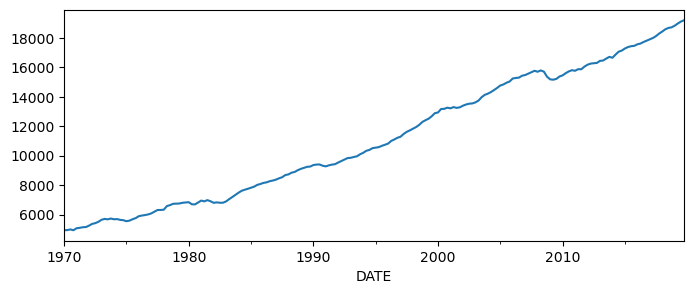

In [80]:
data = pd.read_csv('data7_GDP_Q_real_SA.csv', header=0, index_col=0)
data.index = pd.to_datetime(data.index)
data = data['1970':'2019']
data.columns = ['gdp']
data.gdp.plot(figsize=(8,3))

In [82]:
model_gdp = ARIMA(data.gdp, order=(1,1,1))
res_gdp = model_gdp.fit()
res_gdp.summary()


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    gdp   No. Observations:                  200
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1133.803
Date:                Mon, 03 Mar 2025   AIC                           2273.607
Time:                        14:06:16   BIC                           2283.486
Sample:                    01-01-1970   HQIC                          2277.605
                         - 10-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9403      0.032     29.056      0.000       0.877       1.004
ma.L1         -0.5901      0.065     -9.053      0.000      -0.718      -0.462
sigma2      5176.8764    385.449     13.431      0.000    4421.410    5932.343
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                62.40
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               1.55   Skew:                            -0.52
Prob(H) (two-sided):                  0.08   Kurtosis:                         5.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [84]:
train = data.gdp[:180]
test = data.gdp[180:]

In [86]:
model_gdp = ARIMA(train, order=(1,1,1))
res_gdp = model_gdp.fit()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [88]:
fc = res_gdp.get_forecast(steps=20).summary_frame()

In [90]:
fc.head()

gdp,mean,mean_se,mean_ci_lower,mean_ci_upper
2015-01-01,17238.629220,74.583425,17092.448392,17384.810048
2015-04-01,17329.151778,125.362376,17083.446037,17574.857520
2015-07-01,17413.287507,177.099567,17066.178733,17760.396280
2015-10-01,17491.487028,230.612778,17039.494289,17943.479768
2016-01-01,17564.169173,285.747446,17004.114471,18124.223875


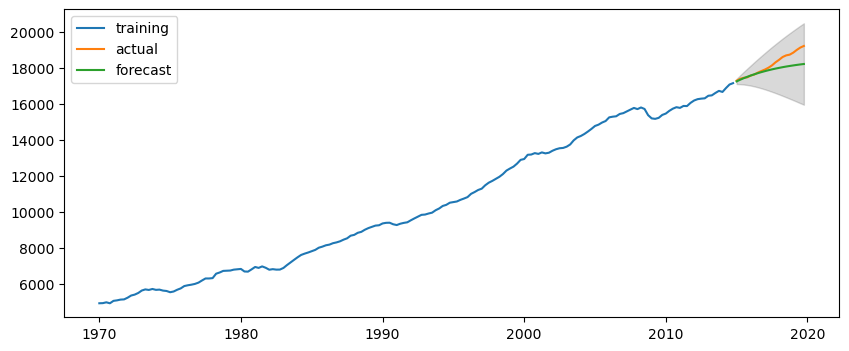

In [94]:
plt.figure(figsize=(10,4))
plt.plot(train,label='training')
plt.plot(test, label = 'actual')
plt.plot(fc['mean'], label='forecast')
plt.fill_between(fc.index, fc.mean_ci_lower, fc.mean_ci_upper, color='k', alpha=0.15)
plt.legend(loc='upper left', fontsize=10)

In [96]:
def forecast_accuracy(forecast, actual):
    mae = np.mean(np.abs(forecast - actual))
    rmse = np.mean((forecast-actual)**2)**.5
    return({'mae':mae, 'rmse':rmse})

In [98]:
forecast_accuracy(fc['mean'],test.values)

{'mae': 339.16792023849814, 'rmse': 478.11351046716914}